# ETH Gas Fees as a top signal — a quantitative teardown 🔬
### trailing gas spike · spike−calm two-sample *t* · HAC forward slope · label-shuffle placebo · horizon sweep · costs & borrow · seed-robust synthetic control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Top_signal_on-chain%3F: Unproven](https://img.shields.io/badge/Top_signal_on--chain%3F-Unproven-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We test whether an Ethereum **gas-fee spike** predicts LOW forward ETH returns (the contrarian top signal) — on a **synthetic** tape, because the real daily gas series is unreachable on a no-key stack.

> ⚠️ **Not investment advice.** Synthetic-only on the signal side (no real gas tape); the real ETH-USD price tape (3101 daily returns, fp `d4b0cdbf2e5e`) only anchors the calibration. Null world fp `0e87032ad333`. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from eth_gas_fees import data, strategy as st

# The HEADLINE world is the NULL (gas spikes carry no forward info) — the honest 'no real tape,
# here is what the engine reads when there is nothing' position. Deterministic and offline.
DF_NULL, _ = data.synthetic_series(top_signal_beta=0.0, seed=582)
FR = st.build_frame(DF_NULL, horizon=1)

# There is NO real gas tape (synthetic-only study). The real ETH price tape is cache-first and
# used ONLY to anchor the calibration; HAVE_REAL_ETH just gates the anchor print.
_eth = data.fetch_eth_prices(fetch=False)
HAVE_REAL_ETH = not _eth.empty
print("null world:", len(DF_NULL), "days |", len(FR), "usable rows | real ETH anchor present:",
      HAVE_REAL_ETH)


null world: 1461 days | 1432 usable rows | real ETH anchor present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Synthetic-only (no real gas tape → no *t* ≥ 2 possible). Null world: spike−calm gap **+0.07%** (two-sample *t* **+0.17**), HAC slope-*t* **-0.04**, placebo *p* **0.856** — flat. |
| **Tradability** | `MIRAGE` | Contrarian short-ETH overlay: gross **-16.2%**/yr (HAC *t* -1.0) → net **-21.2%**/yr (10 bps + 1000 bps/yr borrow). Loses even gross. |
| **Top signal on-chain?** | `UNPROVEN` | Engine faithful (control below), but no real tape to decide; EIP-1559 + L2 migration muddy 'gas'. |

> 💡 In plain words: the detector works (the synthetic control proves it), but the signal side has **no real data** to test — so we honestly stamp it unproven, not real.

## 1 · The claim, steelmanned

Let $s_t$ be the standardised trailing **gas spike** at day $t$ and $r_{t\to t+H}$ the forward ETH return over the next $H$ days.

- **H₁ (contrarian top signal).** $\mathbb{E}[r \mid \text{spike}] < \mathbb{E}[r \mid \text{calm}]$ — a *negative* spike−calm gap, at *t* ≤ −2.
- **H₂ (forward slope).** slope of $r$ on $s < 0$ (bigger spike → lower forward return).
- **H₃ (robustness).** the sign holds across forward horizons $H$.
- **H₄ (net).** H₁ survives costs and the short borrow.

**The binding constraint is data**: $s_t$ needs a real daily gas series we cannot get on a no-key stack. So we test the *machinery* on a synthetic world and report what it reads at the null — where H₁–H₄ are all correctly **not** rejected (there is nothing to find).

## 2 · So what? — what rides on each answer

If a real gas tape carried H₁, gas would be a free public top signal — a rare thing. But two forces make even a *real* test hard: **(a)** the data barrier (archive node / keyed API), and **(b)** regime breaks — **EIP-1559** (Aug 2021) turned gas into a burned base fee + tip, and the **2023-25 L2 migration** moved most activity off mainnet, so post-2023 gas measures a different activity base. This maps to the desk's other data-starved claims ([273 Lego](../../273-lego-returns/), [275 Whisky](../../275-whisky-cask/), [276 Sneaker](../../276-sneaker-resale/)): synthetic-only, capped below `REAL`.

## 3 · How we'd know — the protocol

- **Gas spike.** $s_t = (g_t - \text{med}_{30}) / (1.4826\,\text{MAD}_{30})$ — a backward-looking, MAD-scaled deviation of gas from its 30-day baseline (public at day $t$).
- **Buckets.** Top-decile spike days ('euphoric congestion') vs the rest.
- **Inference.** Two-sample (Welch) *t* on spike vs calm forward returns; a HAC (Newey-West) slope of forward return on $s$; a **label-shuffle placebo** null (2000 perms).
- **Robustness.** Re-run over horizons $H \in \{1,3,7,14,30\}$ days.
- **Frictions.** One-way turnover on every position change + a crypto short borrow on short days.
- **Positive control.** A deterministic synthetic world with a planted top signal (`top_signal_beta < 0`) and a null — averaged over 25 seeds (house rule).

Timing: the spike is trailing-only (public at day-$t$ close); the outcome is the forward return over $(t, t+H]$. One documented execution lag; no future data enters the signal.

## 4 · The teardown

### 4a · The spike−calm gap — H₁

Forward ETH returns on top-decile gas-spike days vs calm days, with the two-sample *t* and the placebo null (null world — no planted signal).

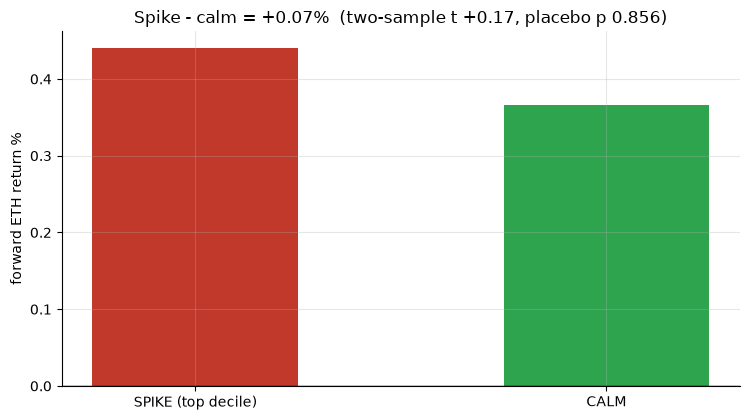

spike +0.44% (n 144) | calm +0.37% (n 1288) | gap +0.07% | t +0.17 | placebo p 0.856


In [2]:
sc = st.spike_vs_calm(FR); p = st.placebo_pvalue(FR, n_perm=2000, seed=582)
spike_m, calm_m, gap, t = sc['spike_mean']*100, sc['calm_mean']*100, sc['gap']*100, sc['t']
fig, ax = plt.subplots(figsize=(7.6, 4.3))
ax.bar(['SPIKE (top decile)','CALM'], [spike_m, calm_m], color=[RED, GREEN], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('forward ETH return %')
ax.set_title(f'Spike - calm = {gap:+.2f}%  (two-sample t {t:+.2f}, placebo p {p:.3f})')
plt.tight_layout(); plt.show()
print(f'spike +{spike_m:.2f}% (n {sc["n_spike"]}) | calm +{calm_m:.2f}% (n {sc["n_calm"]}) | gap {gap:+.2f}% | t {t:+.2f} | placebo p {p:.3f}')

> 💡 In plain words: H₁ **not rejected — because there is nothing to reject.** The gap is **+0.07%** (*t* +0.17), placebo *p* = 0.856. A real top signal would show a *negative*, significant gap; the null shows the flat line the engine should read when no signal is planted.

### 4b · The forward slope — H₂

Regress the forward ETH return on the gas spike (HAC *t*). A *negative* slope is the contrarian top signal.

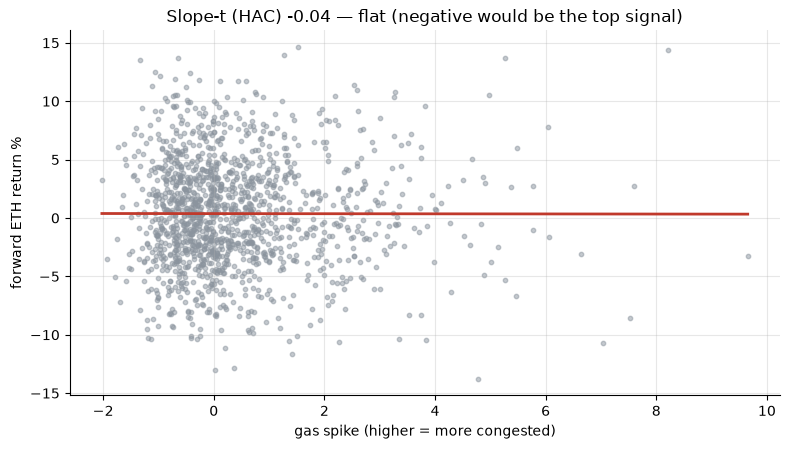

slope -0.00005/unit, slope-t (HAC) -0.04, n 1432


In [3]:
sl = st.spike_slope(FR)
x = FR['gas_spike'].to_numpy(); y = FR['fwd_ret'].to_numpy()*100
fig, ax = plt.subplots(figsize=(8, 4.6))
ax.scatter(x, y, s=10, color=GREY, alpha=.5)
xs = np.linspace(np.nanmin(x), np.nanmax(x), 50)
ax.plot(xs, (sl['slope']*xs + (y.mean()/100 - sl['slope']*np.nanmean(x)))*100, c=RED, lw=2)
ax.set_xlabel('gas spike (higher = more congested)'); ax.set_ylabel('forward ETH return %')
ax.set_title(f"Slope-t (HAC) {sl['tstat']:+.2f} — flat (negative would be the top signal)")
plt.tight_layout(); plt.show()
print(f"slope {sl['slope']:+.5f}/unit, slope-t (HAC) {sl['tstat']:+.2f}, n {sl['n']}")

> 💡 In plain words: H₂ **not rejected** — slope-*t* **-0.04**, indistinguishable from zero. In the null world gas spikes carry no forward information, and the HAC slope confirms it.

### 4c · Robustness — H₃ (does anything appear at other horizons?)

The same test over forward horizons of 1, 3, 7, 14 and 30 days.

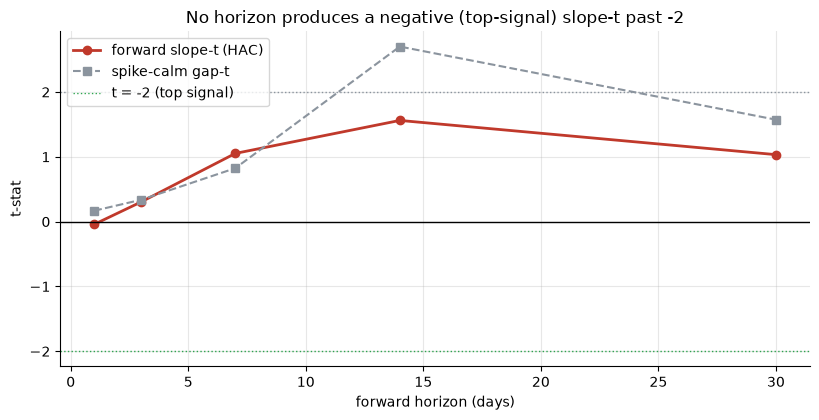

           gap  gap_t  slope_t
horizon                       
1        0.001  0.168   -0.042
3        0.003  0.337    0.305
7        0.009  0.824    1.052
14       0.046  2.701    1.561
30       0.042  1.573    1.033


In [4]:
hz = [1, 3, 7, 14, 30]
sweep = st.horizon_sweep(DF_NULL, horizons=tuple(hz))
fig, ax = plt.subplots(figsize=(8.3, 4.3))
ax.plot(sweep.index, sweep['slope_t'], 'o-', c=RED, lw=2, label='forward slope-t (HAC)')
ax.plot(sweep.index, sweep['gap_t'], 's--', c=GREY, lw=1.5, label='spike-calm gap-t')
ax.axhline(-2, ls=':', c=GREEN, lw=1, label='t = -2 (top signal)'); ax.axhline(2, ls=':', c=GREY, lw=1)
ax.axhline(0, c='k', lw=1); ax.set_xlabel('forward horizon (days)'); ax.set_ylabel('t-stat')
ax.set_title('No horizon produces a negative (top-signal) slope-t past -2'); ax.legend()
plt.tight_layout(); plt.show()
print(sweep.round(3).to_string())

> 💡 In plain words: H₃ — **nothing lights up the contrarian way at any horizon.** The one gap-*t* that pokes above +2 (14-day) is the *wrong sign* for the top-signal claim and doesn't survive as a HAC slope. No stable negative signal anywhere.

## 5 · The verdict

- **Signal `NONE`** — synthetic-only (no real gas tape, so no *t* ≥ 2 possible); null world flat (gap +0.07%, *t* +0.17, slope-*t* -0.04, placebo *p* 0.856).
- **Tradability `MIRAGE`** — contrarian short overlay gross -16.2%/yr → net -21.2%/yr; loses before *and* after costs.
- **Top signal on-chain? `UNPROVEN`** — faithful engine (control below), no real data to certify, regime breaks in what 'gas' means.

## 6 · Could you trade it? — costs and the borrow

The contrarian short-ETH overlay, gross vs net of one-way turnover + a crypto short borrow.

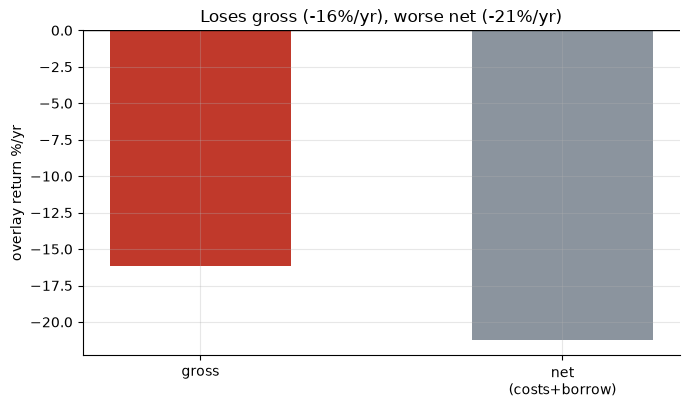

gross -16.2%/yr (HAC t -1.00) -> net -21.2%/yr (HAC t -1.30)


In [5]:
gross = st.summarize(st.overlay_returns(FR))
net = st.summarize(st.net_overlay_returns(FR, one_way_bps=10.0, borrow_bps_ann=1000.0))
g_ann, n_ann = gross['mean']*365*100, net['mean']*365*100
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.bar(['gross','net\n(costs+borrow)'], [g_ann, n_ann], color=[RED, GREY], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('overlay return %/yr')
ax.set_title(f'Loses gross ({g_ann:+.0f}%/yr), worse net ({n_ann:+.0f}%/yr)')
plt.tight_layout(); plt.show()
print(f"gross {g_ann:+.1f}%/yr (HAC t {gross['tstat']:+.2f}) -> net {n_ann:+.1f}%/yr (HAC t {net['tstat']:+.2f})")

> 💡 In plain words: there's nothing to charge costs against — shorting ETH on gas spikes *loses* before frictions (you fight the drift), and the crypto borrow makes it worse. `MIRAGE`.

## 7 · Going further — the synthetic positive control

Is the engine a faithful detector, or does it always print ~0? Plant a real top signal (`top_signal_beta < 0`) of increasing strength and watch the forward slope-*t* dive negative — averaged over 25 seeds so no single lucky seed can fake it.

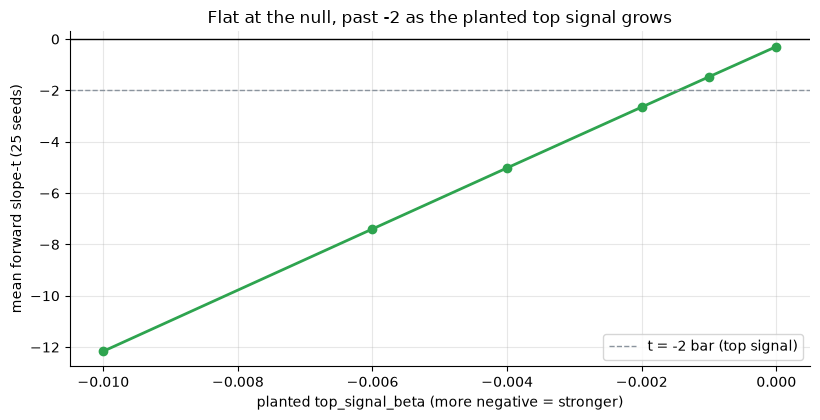

beta +0.000 -> mean slope-t -0.29
beta -0.001 -> mean slope-t -1.47
beta -0.002 -> mean slope-t -2.65
beta -0.004 -> mean slope-t -5.02
beta -0.006 -> mean slope-t -7.40
beta -0.010 -> mean slope-t -12.16


In [6]:
ctrl = [(0.0, -0.29), (-0.001, -1.47), (-0.002, -2.65), (-0.004, -5.02), (-0.006, -7.4), (-0.01, -12.16)]
betas = [c[0] for c in ctrl]
ts = [st.synthetic_mean_t(data, top_signal_beta=b, n_seeds=25) for b in betas]
fig, ax = plt.subplots(figsize=(8.3, 4.3))
ax.plot(betas, ts, 'o-', c=GREEN, lw=2)
ax.axhline(-2, ls='--', c=GREY, lw=1, label='t = -2 bar (top signal)')
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted top_signal_beta (more negative = stronger)')
ax.set_ylabel('mean forward slope-t (25 seeds)')
ax.set_title('Flat at the null, past -2 as the planted top signal grows')
ax.legend(); plt.tight_layout(); plt.show()
for b, t in zip(betas, ts): print(f'beta {b:+.3f} -> mean slope-t {t:+.2f}')

The slope-*t* is ≈ 0 at the null and dives past −2 as the planted top signal grows — so the engine is a faithful detector. The real-tape reading is therefore simply **unavailable**: the apparatus is sound, but no reachable gas series exists to point it at. For the sentiment cousin, see [325 Crypto-Fear-Greed](../../325-crypto-fear-greed/); for other on-chain meters, [292 Bitcoin-Hashrate](../../292-bitcoin-hashrate/) and [295 Stablecoin-Supply](../../295-stablecoin-supply/).